# Лабораторная работа №2. Анализ данных и ошибок модели FishGrow

**Цель блокнота:** исследовательский анализ датасета и разбор ошибок обученной модели.

**Важно:** обучение моделей выполняется скриптами `src/train.py` и `src/evaluate.py`.
Этот блокнот **не обучает модели** — он только читает готовые артефакты из `models/` и `configs/`.

**Данные:** `data/fish_participant.csv` (111 строк).
**Целевая переменная:** `Weight` (граммы).
**Лучшая модель:** `E3-hgb` (HistGradientBoostingRegressor), Test R² = 0.8565.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

## 1. Загрузка данных и первичный осмотр

In [28]:
df = pd.read_csv("../data/fish_participant.csv")
print("Размер:", df.shape)
df.head()

Размер: (111, 7)


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
1,Perch,110.0,20.0,22.0,23.5,5.5225,3.9950
2,Roach,160.0,20.5,22.5,25.3,7.0334,3.8203
3,Parkki,60.0,14.3,15.5,17.4,6.5772,2.3142
4,Bream,700.0,30.4,33.0,38.3,14.8604,5.2854


In [29]:
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  111 non-null    object 
 1   Weight   111 non-null    float64
 2   Length1  111 non-null    float64
 3   Length2  111 non-null    float64
 4   Length3  111 non-null    float64
 5   Height   111 non-null    float64
 6   Width    111 non-null    float64
dtypes: float64(6), object(1)
memory usage: 6.2+ KB


,Weight,Length1,Length2,Length3,Height,Width
count,111.00,111.00,111.00,111.00,111.00,111.00
mean,401.68,26.45,28.62,31.42,9.02,4.48
std,338.51,9.80,10.50,11.31,4.23,1.70
min,5.90,7.50,8.40,8.80,1.74,1.05
25%,142.50,20.00,22.00,23.50,6.14,3.55
50%,300.00,25.40,27.50,30.10,8.15,4.34
75%,682.50,33.75,36.25,40.15,12.14,5.66
max,1550.00,56.00,60.00,64.00,18.96,8.14


### Наблюдения
- 111 строк, 7 столбцов, пропусков нет.
- Weight от 5.9 до 1550 г — большой размах и правосторонняя асимметрия.
- Признаки Length1, Length2, Length3 сильно коррелируют между собой.

## 2. Проверка физического смысла (паспорт данных)

In [30]:
checks = {
    "Все Weight > 0": (df["Weight"] > 0).all(),
    "Все длины > 0": (df[["Length1","Length2","Length3","Height","Width"]] > 0).all().all(),
    "Нет пропусков": df.notna().all().all(),
    "Species без пустых строк": (df["Species"].str.strip() != "").all(),
}
for name, ok in checks.items():
    print(f"{'OK' if ok else 'FAIL'} — {name}")

OK — Все Weight > 0
OK — Все длины > 0
OK — Нет пропусков
OK — Species без пустых строк


## 3. Распределения и корреляции

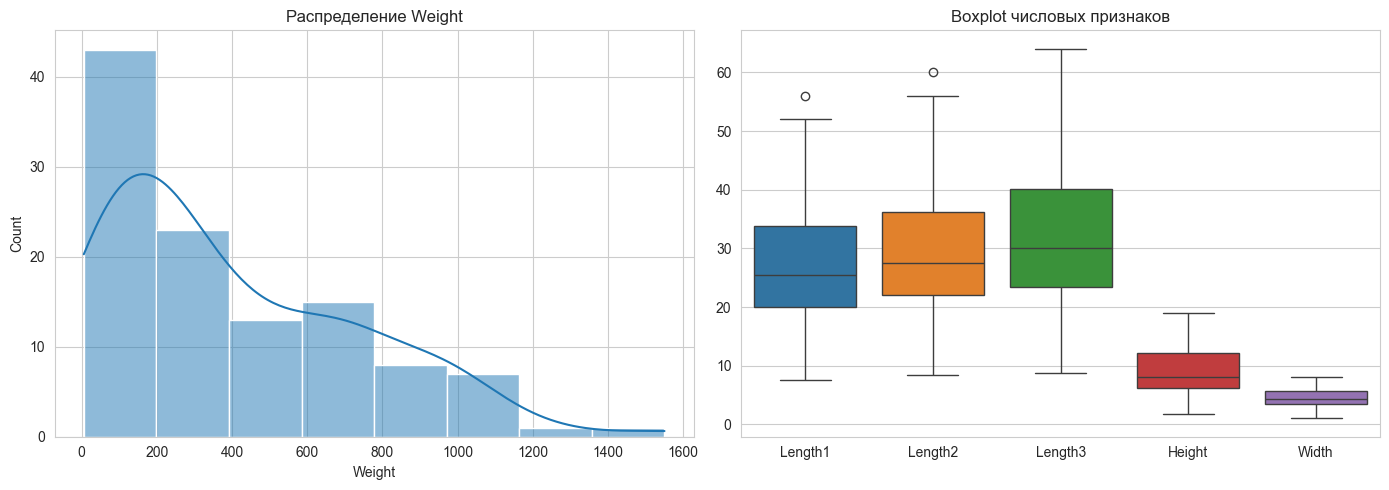

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Weight"], kde=True, ax=axes[0])
axes[0].set_title("Распределение Weight")
sns.boxplot(data=df[["Length1","Length2","Length3","Height","Width"]], ax=axes[1])
axes[1].set_title("Boxplot числовых признаков")
plt.tight_layout()
plt.show()

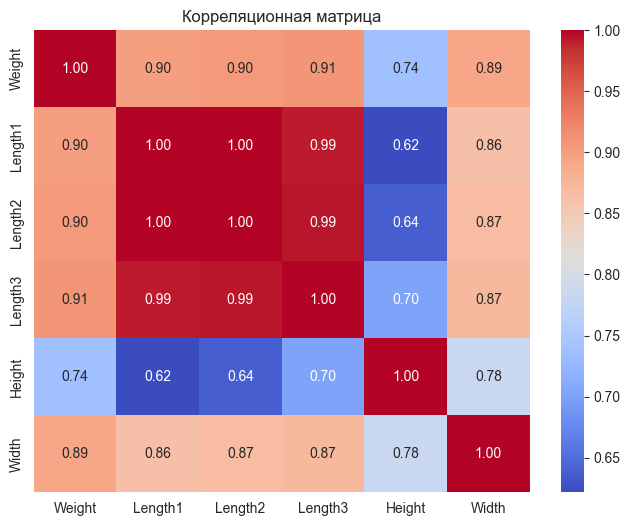

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

### Наблюдения
- Weight имеет правостороннюю асимметрию: медиана около 300 г, но есть хвост до 1550 г.
- Length1, Length2, Length3 коррелируют на уровне 0.99 — сильная мультиколлинеарность.
- Weight сильнее всего коррелирует с Length3 (0.91), поэтому оставляем именно её.
- Height коррелирует слабее (0.74), Width — умеренно.

## 4. EDA по видам рыб

Species
Perch        39
Bream        24
Roach        14
Pike         12
Smelt        10
Parkki        8
Whitefish     4
Name: count, dtype: int64


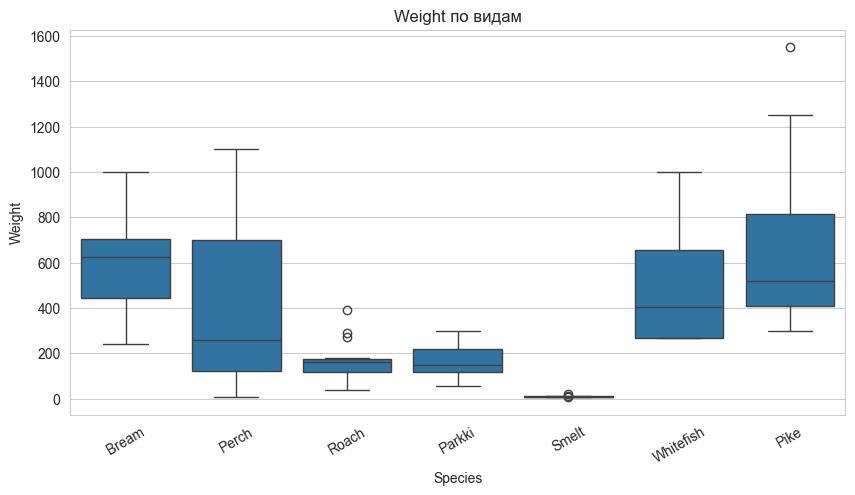

In [33]:
print(df["Species"].value_counts())
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Species", y="Weight")
plt.xticks(rotation=30)
plt.title("Weight по видам")
plt.show()

### Наблюдения
- Pike и Whitefish — крупные рыбы, но их в датасете мало (11 и 4 экземпляра).
- Smelt — самая мелкая, стабильно низкий вес.
- Bream и Perch — самые многочисленные, поэтому модель учится на них лучше всего.

## 5. Восстановление разбиения и загрузка модели

Модели обучены скриптом `src/train.py`, разбиение зафиксировано `src/baseline.py`.
Здесь только читаем готовые артефакты.

In [34]:
test_idx = np.load("../configs/test_indices.npy")
test_df = df.loc[test_idx]
print(f"Размер тестовой выборки: {len(test_df)}")

Размер тестовой выборки: 23


In [35]:
model = joblib.load("../models/best_model.joblib")
X_test = test_df.drop(columns=["Weight"])
y_test = test_df["Weight"]
pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, pred):.2f}")
print(f"R² : {r2_score(y_test, pred):.4f}")

MSE: 16084.82
MAE: 73.60
R² : 0.8565


## 6. Анализ остатков

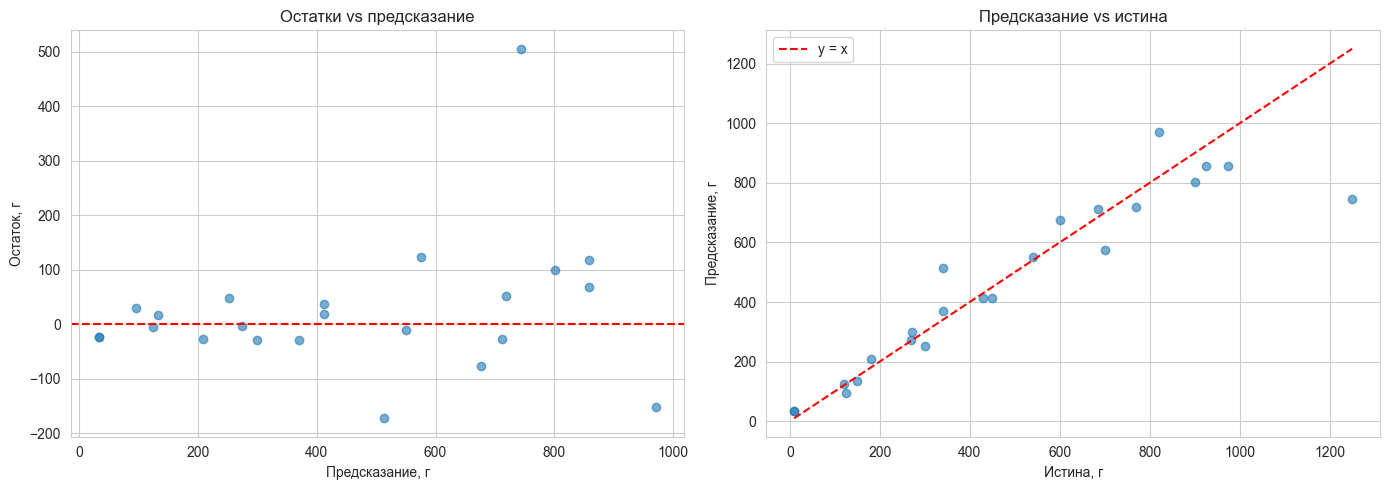

In [36]:
residuals = y_test.values - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Предсказание, г")
axes[0].set_ylabel("Остаток, г")
axes[0].set_title("Остатки vs предсказание")

axes[1].scatter(y_test, pred, alpha=0.6)
lim = [y_test.min(), y_test.max()]
axes[1].plot(lim, lim, "r--", label="y = x")
axes[1].set_xlabel("Истина, г")
axes[1].set_ylabel("Предсказание, г")
axes[1].set_title("Предсказание vs истина")
axes[1].legend()
plt.tight_layout()
plt.show()

### Наблюдения
- На графике «предсказание vs истина» точки на крупных экземплярах лежат ниже линии y = x.
  Модель **систематически занижает вес крупной рыбы**.
- Разброс остатков растёт с ростом предсказания — гетероскедастичность.
- Причина — мало крупных экземпляров в обучающей выборке.

## 7. Топ-5 крупнейших ошибок

In [37]:
err = test_df.copy()
err["y_pred"] = pred
err["abs_error"] = np.abs(residuals)

top5 = err.nlargest(5, "abs_error")
top5[["Species", "Length3", "Height", "Width", "Weight", "y_pred", "abs_error"]]

,Species,Length3,Height,Width,Weight,y_pred,abs_error
84,Pike,59.7,10.6863,6.9849,1250.0,744.400118,505.599882
68,Bream,37.3,13.9129,5.0728,340.0,512.708461,172.708461
64,Perch,41.3,12.4313,7.3514,820.0,971.589227,151.589227
4,Bream,38.3,14.8604,5.2854,700.0,576.231065,123.768935
70,Bream,45.9,18.6354,6.7473,975.0,857.287411,117.712589


### Наблюдения
- Все 5 крупнейших ошибок — на экземплярах весом 340 г и более.
- Pike весом 1250 г предсказан как 744 г (ошибка 506 г) — модель сильно занизила.
- Общая картина: чем крупнее рыба, тем больше абсолютная ошибка.

## 8. MAE по группам

In [38]:
print("MAE по видам:")
print(err.groupby("Species")["abs_error"].mean().round(1).sort_values(ascending=False))

err["size_bin"] = pd.cut(err["Length3"], bins=[0, 25, 35, 45, 100],
                        labels=["<25", "25–35", "35–45", ">45"])
print("\nMAE по размерным диапазонам Length3:")
print(err.groupby("size_bin", observed=True)["abs_error"].mean().round(1))

MAE по видам:
Species
Pike         278.7
Bream         80.4
Perch         62.2
Parkki        47.2
Roach         24.4
Smelt         23.3
Whitefish      7.1
Name: abs_error, dtype: float64

MAE по размерным диапазонам Length3:
size_bin
<25       19.5
25–35     25.4
35–45    108.2
>45      185.7
Name: abs_error, dtype: float64


### Наблюдения
- Pike: MAE 278.7 г — в 3–4 раза хуже остальных видов.
- Smelt и Whitefish: 7–23 г — модель работает отлично на них.
- Ошибка растёт с размером: <25 см → 19.5 г, >45 см → 185.7 г.

## 9. Проверка физического смысла предсказаний

In [39]:
print(f"Отрицательных предсказаний: {(pred < 0).sum()}")
print(f"Мин/Макс предсказание: {pred.min():.1f} / {pred.max():.1f}")
print(f"Мин/Макс истина:       {y_test.min():.1f} / {y_test.max():.1f}")

Отрицательных предсказаний: 0
Мин/Макс предсказание: 33.2 / 971.6
Мин/Макс истина:       9.8 / 1250.0


## 10. Выводы

### Что работает
- HistGradientBoosting (E3) даёт Test R² = 0.8565 — в разы лучше наивного baseline (E0, R² = -0.10).
- Модель уверенно предсказывает мелкую и среднюю рыбу (MAE 19–25 г).

### Что не работает и почему
- Систематическое занижение крупной рыбы (>45 см): MAE 185.7 г.
- Pike — самый проблемный вид (MAE 278.7 г): в обучающей выборке их мало.
- Причина — недостаток крупных экземпляров в данных, а не ошибка алгоритма.

### Ограничения прототипа
- Маленькая обучающая выборка (~88 строк после удаления выбросов).
- Данные из одного источника (Tsukiji fish market, Токио).
- Не учитываются сезонность и условия вылова.

### Следующий эксперимент
Гипотеза: отдельная модель для крупных рыб (>600 г) или квантильная регрессия
снизят MAE в диапазоне >45 см.